# Target Distribution EDA

Decide: log-transform vs raw ratio for Model B and Model C targets.

- **Model B target**: `price / ref_base_price`
- **Model C target**: `price / ref_predicted_price`

Decision rule: apply log when `max/median > ~5` OR `|skew| > 1.5`. Document result in `docs/target_choice.md`.

## 1. Connect + Pull

In [19]:
import clickhouse_connect
import polars as pl
import pandas as pd

client = clickhouse_connect.get_client(host='localhost', port=8023, username='default', password='golub383')

query = """
SELECT
    id,
    sold_at,
    price,
    ref_base_price,
    ref_predicted_price,
    market_hash_name,
    wear_name,
    is_stattrak,
    is_souvenir,
    float_value,
    length(stickers) AS n_stickers,
    _snapshot_date
FROM default.csfloat_sales FINAL
"""

df: pd.DataFrame | pl.DataFrame = client.query_df(query)
df = pl.from_pandas(df) if isinstance(df, pd.DataFrame) else df
print(f"Rows: {len(df):,}")
df.head(5)


Rows: 230,694


id,sold_at,price,ref_base_price,ref_predicted_price,market_hash_name,wear_name,is_stattrak,is_souvenir,float_value,n_stickers,_snapshot_date
str,datetime[μs],i32,i32,i32,str,str,bool,bool,f32,u64,datetime[ms]
"""969781653285241315""",2026-06-06 02:52:18.357062,50,62,62,"""PP-Bizon | Lumen (Field-Tested…","""Field-Tested""",false,false,0.32486,0,2026-06-23 00:00:00
"""973751102505879376""",2026-05-21 23:07:09.812801,55,55,55,"""PP-Bizon | Lumen (Field-Tested…","""Field-Tested""",false,false,0.3411,0,2026-06-23 00:00:00
"""973751103202133846""",2026-05-21 23:07:09.812801,55,55,55,"""PP-Bizon | Lumen (Field-Tested…","""Field-Tested""",false,false,0.304787,0,2026-06-23 00:00:00
"""974460244858111978""",2026-06-10 08:51:01.028996,78,61,61,"""PP-Bizon | Lumen (Field-Tested…","""Field-Tested""",false,false,0.18762,0,2026-06-23 00:00:00
"""974460246170929140""",2026-06-10 08:51:01.028996,78,61,61,"""PP-Bizon | Lumen (Field-Tested…","""Field-Tested""",false,false,0.178063,0,2026-06-23 00:00:00


## 2. Data Quality

In [20]:
total = len(df)

bad_base   = (df['ref_base_price'] <= 0).sum()
bad_pred   = (df['ref_predicted_price'] <= 0).sum()
bad_price  = (df['price'] <= 0).sum()

print(f"Total rows          : {total:,}")
print(f"ref_base_price <= 0 : {bad_base:,}  ({bad_base/total:.2%})")
print(f"ref_predicted  <= 0 : {bad_pred:,}  ({bad_pred/total:.2%})")
print(f"price <= 0          : {bad_price:,}  ({bad_price/total:.2%})")

# Drop rows where either denominator is zero
df_clean = df.filter(
    (pl.col('ref_base_price') > 0) &
    (pl.col('ref_predicted_price') > 0) &
    (pl.col('price') > 0)
)
print(f"\nRows after quality filter: {len(df_clean):,} (dropped {total - len(df_clean):,})")

Total rows          : 230,694
ref_base_price <= 0 : 0  (0.00%)
ref_predicted  <= 0 : 0  (0.00%)
price <= 0          : 0  (0.00%)

Rows after quality filter: 230,694 (dropped 0)


## 3. Compute Targets + Apex Outlier Identification

In [23]:
thresh = 10.0  

df_clean = df_clean.with_columns([
    (pl.col('price') / pl.col('ref_base_price')).alias('target_b'),
    (pl.col('price') / pl.col('ref_predicted_price')).alias('target_c'),
])

apex_b = df_clean.filter(pl.col('target_b') > thresh)
apex_c = df_clean.filter(pl.col('target_c') > thresh)

print(f"Apex outliers (target_b > {thresh}): {len(apex_b):,}")
print(apex_b.select(['market_hash_name', 'wear_name', 'float_value', 'target_b', 'target_c'])
      .sort('target_b', descending=True).head(20).to_pandas().to_string(index=False))

print(f"\nApex outliers (target_c > {thresh}): {len(apex_c):,}")
print(apex_c.select(['market_hash_name', 'wear_name', 'float_value', 'target_b', 'target_c'])
      .sort('target_c', descending=True).head(20).to_pandas().to_string(index=False))

Apex outliers (target_b > 10.0): 2,486
                        market_hash_name      wear_name  float_value  target_b     target_c
       G3SG1 | Green Cell (Field-Tested)   Field-Tested     0.276660   86000.0 86000.000000
              AUG | Storm (Field-Tested)   Field-Tested     0.267939   73937.0 73937.000000
              AUG | Storm (Field-Tested)   Field-Tested     0.267939   67500.0 67500.000000
SG 553 | Waves Perforated (Field-Tested)   Field-Tested     0.218558   33999.0 33999.000000
        SSG 08 | Blue Spruce (Well-Worn)      Well-Worn     0.385266   28446.0 28446.000000
           MP9 | Bee-Tron (Field-Tested)   Field-Tested     0.268274   21932.0 21932.000000
   Five-SeveN | Forest Night (Well-Worn)      Well-Worn     0.425646   15851.0 15851.000000
       Galil AR | Sage Spray (Well-Worn)      Well-Worn     0.391342   14931.0 14931.000000
SG 553 | Waves Perforated (Field-Tested)   Field-Tested     0.379817   13875.0 13875.000000
    Tec-9 | Urban DDPAT (Battle-Scarred) 

## 4. Distribution Stats

In [24]:
import numpy as np
from scipy import stats

def dist_stats(series: pl.Series, label: str) -> None:
    arr = series.drop_nulls().to_numpy()
    median = np.median(arr)
    print(f"\n--- {label} ---")
    print(f"  n          : {len(arr):,}")
    print(f"  min        : {arr.min():.4f}")
    print(f"  p25        : {np.percentile(arr, 25):.4f}")
    print(f"  median     : {median:.4f}")
    print(f"  p75        : {np.percentile(arr, 75):.4f}")
    print(f"  max        : {arr.max():.4f}")
    print(f"  max/median : {arr.max() / median:.2f}")
    print(f"  mean       : {arr.mean():.4f}")
    print(f"  std        : {arr.std():.4f}")
    print(f"  skew       : {stats.skew(arr):.4f}")
    print(f"  kurtosis   : {stats.kurtosis(arr):.4f}")

df_filtered = df_clean.filter(
    (pl.col('target_b') <= thresh) &
    (pl.col('target_c') <= thresh)
)
print(f"Rows after apex filter: {len(df_filtered):,} (removed {len(df_clean) - len(df_filtered):,} apex outliers)")

# Stats with apex outliers (full set)
print("\n=== With apex outliers ===")
dist_stats(df_clean['target_b'], 'Model B  (price / ref_base_price)')
dist_stats(df_clean['target_c'], 'Model C  (price / ref_predicted_price)')

# Stats without apex outliers (filtered set)
print("\n=== Without apex outliers (ratio <= 10) ===")
dist_stats(df_filtered['target_b'], 'Model B  (price / ref_base_price)')
dist_stats(df_filtered['target_c'], 'Model C  (price / ref_predicted_price)')

Rows after apex filter: 228,195 (removed 2,499 apex outliers)

=== With apex outliers ===

--- Model B  (price / ref_base_price) ---
  n          : 230,694
  min        : 0.0013
  p25        : 0.9497
  median     : 1.0000
  p75        : 1.1456
  max        : 86000.0000
  max/median : 86000.00
  mean       : 5.0250
  std        : 314.6132
  skew       : 201.7439
  kurtosis   : 47723.5984

--- Model C  (price / ref_predicted_price) ---
  n          : 230,694
  min        : 0.0014
  p25        : 0.9546
  median     : 1.0000
  p75        : 1.0915
  max        : 86000.0000
  max/median : 86000.00
  mean       : 4.9207
  std        : 313.9710
  skew       : 202.8796
  kurtosis   : 48112.6547

=== Without apex outliers (ratio <= 10) ===

--- Model B  (price / ref_base_price) ---
  n          : 228,195
  min        : 0.0013
  p25        : 0.9487
  median     : 1.0000
  p75        : 1.1351
  max        : 10.0000
  max/median : 10.00
  mean       : 1.2379
  std        : 0.8134
  skew       : 5.0

## 5. Plots

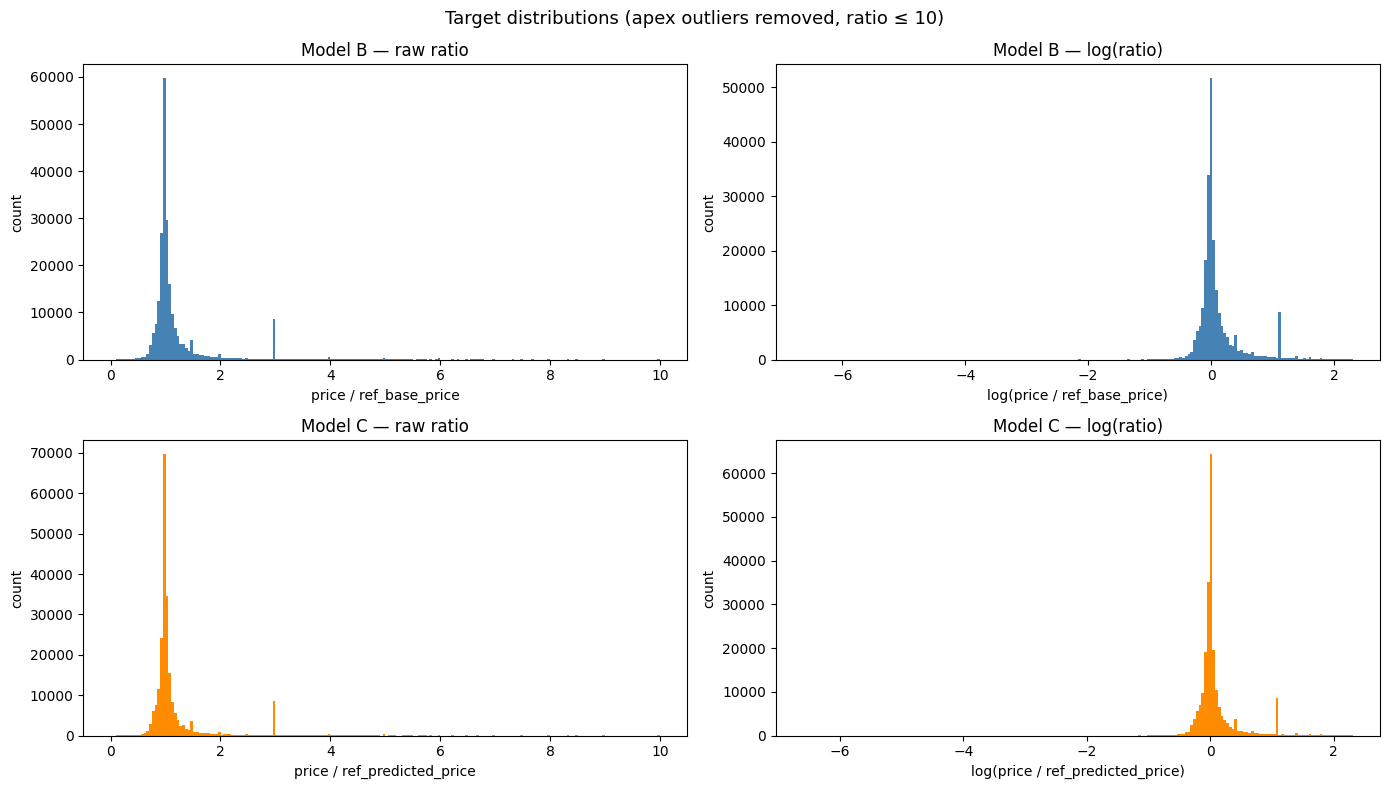

In [25]:
import matplotlib.pyplot as plt

b = df_filtered['target_b'].to_numpy()
c = df_filtered['target_c'].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Target distributions (apex outliers removed, ratio ≤ 10)', fontsize=13)

# Model B raw
axes[0, 0].hist(b, bins=200, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Model B — raw ratio')
axes[0, 0].set_xlabel('price / ref_base_price')
axes[0, 0].set_ylabel('count')

# Model B log
axes[0, 1].hist(np.log(b[b > 0]), bins=200, color='steelblue', edgecolor='none')
axes[0, 1].set_title('Model B — log(ratio)')
axes[0, 1].set_xlabel('log(price / ref_base_price)')
axes[0, 1].set_ylabel('count')

# Model C raw
axes[1, 0].hist(c, bins=200, color='darkorange', edgecolor='none')
axes[1, 0].set_title('Model C — raw ratio')
axes[1, 0].set_xlabel('price / ref_predicted_price')
axes[1, 0].set_ylabel('count')

# Model C log
axes[1, 1].hist(np.log(c[c > 0]), bins=200, color='darkorange', edgecolor='none')
axes[1, 1].set_title('Model C — log(ratio)')
axes[1, 1].set_xlabel('log(price / ref_predicted_price)')
axes[1, 1].set_ylabel('count')

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Decision

Fill in after reviewing stats above. Copy to `docs/target_choice.md`.

```
Model B: [log | raw] — max/median=X, skew=Y
Model C: [log | raw] — max/median=X, skew=Y
Apex outlier threshold: ratio > 10 (N rows removed)
```